In [57]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import datetime
import pytz

NYC_tz = pytz.timezone("America/New_York") 

import sys
sys.path.append("../../")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
from MDP.STIRFutures.STIRFutureOptionMDP import STIRFutureOptionMDP
from Query.STIRFutureOptions.STIRFutureOptionQuery import STIRFutureOptionQuery
from Query.STIRFutureOptions.STIRFutureOptionStructure import STIRFutureOptionStructure
from Query.STIRFutureOptions.STIRFutureOptionValue import STIRFutureOptionValue

In [59]:
stirfo_mdp = STIRFutureOptionMDP(source="BARCHART_STIRFO-QL")

In [60]:
as_of = datetime.date(2026, 3, 23)
# as_of = "live"

q = STIRFutureOptionQuery(
    structure=STIRFutureOptionStructure.OUTRIGHT,
    value=STIRFutureOptionValue.PRICE,
    symbol="SFRZ26|25DC",  
    market_request={
        "endpoint": "option_snapshot",
        "timestamp": as_of,
        "use_ql_calculator": True,
        # "force_refresh": True,
    },
)

req = q.build_mdp_request(as_of)
pr = stirfo_mdp.get_pricer(req)

package, weights = q.resolve_package(pricer_or_curve=pr)
value_map = q.build_value_map(
    pricer_or_curve=pr,
    package=package,
    risk_weights=weights,
)

print("resolved_symbol:", package[0].symbol())
print("price:", value_map.apply(STIRFutureOptionValue.PRICE))
print("iv_normal_bps:", value_map.apply(STIRFutureOptionValue.IV_NORMAL_BPS))
print("delta:", value_map.apply(STIRFutureOptionValue.DELTA))
print("gamma:", value_map.apply(STIRFutureOptionValue.GAMMA))
print("vega:", value_map.apply(STIRFutureOptionValue.VEGA))
print("theta:", value_map.apply(STIRFutureOptionValue.THETA))

resolved_symbol: SFRZ26|9668C
price: 0.195
iv_normal_bps: 104.72062662122796
delta: 0.32782312445463213
gamma: 0.39586599695239966
vega: 0.30438437943515523
theta: -0.2097368966512007


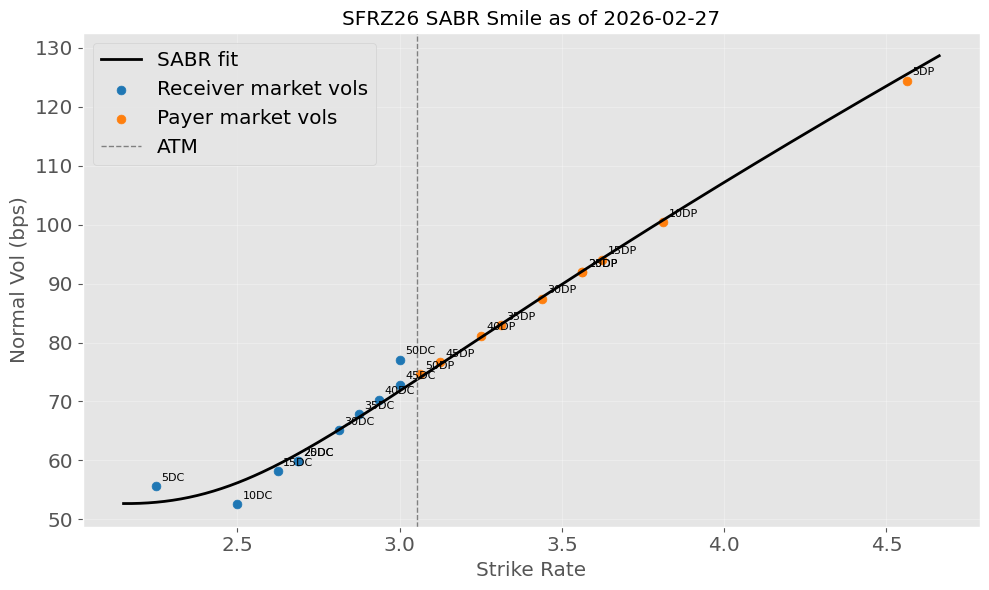

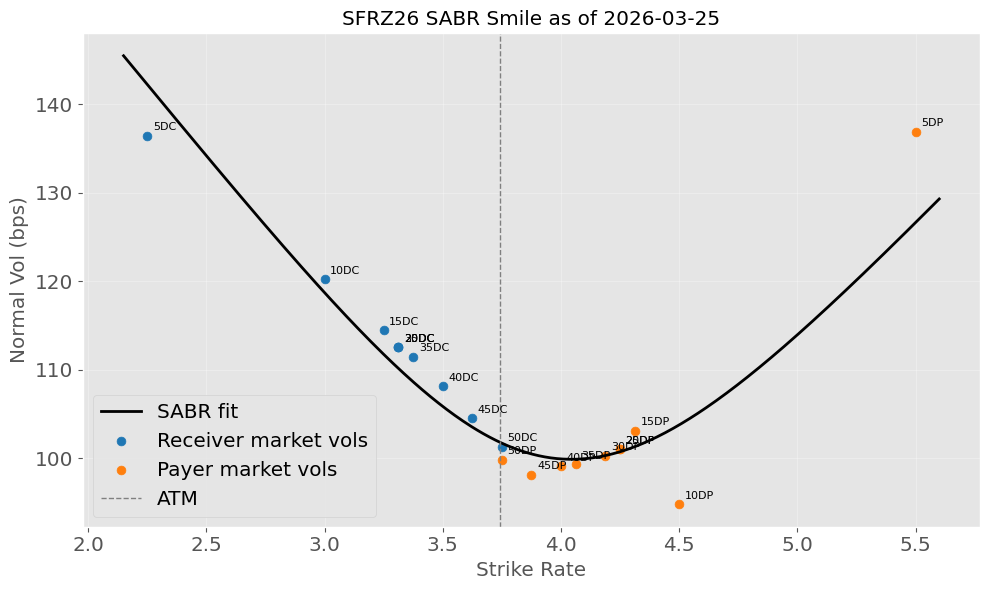

In [ ]:
smile_historical = stirfo_mdp.fetch_sabr_smile(
    {
        "symbol": "SFRZ26",
        "as_of": datetime.date(2026, 2, 27),
        "show_tqdm": True,
        # "strike_offsets_bps": "listed",
    }
)
plot_sfr_smile(smile_historical)
smile_live = stirfo_mdp.fetch_sabr_smile(
    {
        "symbol": "SFRZ26",
        "as_of": "live",
        "show_tqdm": True,
        # "strike_offsets_bps": "listed",
    }
)
plot_sfr_smile(smile_live)

# fig, ax = plot_sabr_smiles(
#     [smile_historical, smile_live],
#     labels=["2026-02-27", "Live"],
#     align_atm=True,
#     y_mode="vol_minus_atm",   # or "vol_ratio_to_atm"
# )
# plt.show()

In [62]:
import numpy as np
import matplotlib.pyplot as plt


def plot_sabr_smiles(
    smiles,
    labels=None,
    *,
    align_atm=True,
    y_mode="vol",               # "vol", "vol_minus_atm", "vol_ratio_to_atm"
    use_market_points=True,
    use_sabr_fit=True,
    strike_pad_rate=0.10,       # in rate units, e.g. 0.10 = 10bp
    n_grid=400,
    annotate=False,
    figsize=(11, 7),
    title=None,
):
    """
    Plot one or more STIRFutureOptionSABRSmile objects.

    Parameters
    ----------
    smiles : list
        List of STIRFutureOptionSABRSmile objects.
    labels : list[str] | None
        Optional legend labels. Defaults to "{symbol} | {as_of}".
    align_atm : bool
        If True, x-axis is strike rate relative to ATM forward rate.
        If False, x-axis is absolute strike rate.
    y_mode : str
        "vol"              -> plot normal vol in bps
        "vol_minus_atm"    -> plot vol - ATM vol in bps
        "vol_ratio_to_atm" -> plot vol / ATM vol
    use_market_points : bool
        Plot market smile points.
    use_sabr_fit : bool
        Plot fitted SABR curve.
    strike_pad_rate : float
        Padding for SABR fit grid in strike-rate units.
    n_grid : int
        Number of points in smooth SABR curve.
    annotate : bool
        Annotate market points with option labels.
    """

    def _default_label(smile):
        return f"{smile.symbol} | {smile.params.as_of}"

    def _dedupe_points(points):
        # Some smiles may contain duplicated strikes / duplicated deltas.
        # Keep first occurrence for plotting cleanliness.
        seen = set()
        out = []
        for p in sorted(points, key=lambda p: (p.strike_rate, p.right, p.label)):
            key = (round(float(p.strike_rate), 10), p.right)
            if key not in seen:
                seen.add(key)
                out.append(p)
        return out

    def _atm_vol_from_points(points, fwd_rate):
        # Prefer explicit ATM point if present; otherwise interpolate nearest strike.
        pts_sorted = sorted(points, key=lambda p: abs(p.strike_rate - fwd_rate))
        if not pts_sorted:
            raise ValueError("Smile has no points.")
        return pts_sorted[0].iv_normal_bps

    if labels is None:
        labels = [_default_label(smile) for smile in smiles]

    if len(labels) != len(smiles):
        raise ValueError("labels must have same length as smiles")

    fig, ax = plt.subplots(figsize=figsize)

    for smile, label in zip(smiles, labels):
        pts = _dedupe_points(smile.points)
        if not pts:
            continue

        fwd = float(smile.params.forward_rate)
        atm_vol = _atm_vol_from_points(pts, fwd)

        put_pts = [p for p in pts if p.right == "P"]
        call_pts = [p for p in pts if p.right == "C"]

        # Smooth strike grid in absolute strike-rate space for model eval
        x_min_abs = min(p.strike_rate for p in pts) - strike_pad_rate
        x_max_abs = max(p.strike_rate for p in pts) + strike_pad_rate
        strike_grid_abs = np.linspace(x_min_abs, x_max_abs, n_grid)

        # SABR fitted vols
        if use_sabr_fit:
            sabr_vols = np.asarray(
                smile.normal_vol(
                    strike_grid_abs,
                    strike_space="rate",
                    vol_units="bps",
                )
            )

            if y_mode == "vol":
                y_fit = sabr_vols
                y_label = "Normal Vol (bps)"
            elif y_mode == "vol_minus_atm":
                y_fit = sabr_vols - atm_vol
                y_label = "Normal Vol - ATM Vol (bps)"
            elif y_mode == "vol_ratio_to_atm":
                y_fit = sabr_vols / atm_vol
                y_label = "Normal Vol / ATM Vol"
            else:
                raise ValueError("y_mode must be one of: vol, vol_minus_atm, vol_ratio_to_atm")

            x_fit = strike_grid_abs - fwd if align_atm else strike_grid_abs
            line, = ax.plot(x_fit, y_fit, lw=2, label=f"{label} SABR")

        # Market points
        if use_market_points:
            def _transform_point_y(p):
                vol = p.iv_normal_bps
                if y_mode == "vol":
                    return vol
                elif y_mode == "vol_minus_atm":
                    return vol - atm_vol
                elif y_mode == "vol_ratio_to_atm":
                    return vol / atm_vol
                else:
                    raise ValueError("invalid y_mode")

            def _transform_point_x(p):
                return p.strike_rate - fwd if align_atm else p.strike_rate

            call_x = [_transform_point_x(p) for p in call_pts]
            call_y = [_transform_point_y(p) for p in call_pts]
            put_x = [_transform_point_x(p) for p in put_pts]
            put_y = [_transform_point_y(p) for p in put_pts]

            # Match scatter color to fitted line color if line exists
            scatter_kwargs = {}
            if use_sabr_fit:
                scatter_kwargs["color"] = line.get_color()

            ax.scatter(call_x, call_y, marker="o", s=40, **scatter_kwargs)
            ax.scatter(put_x, put_y, marker="x", s=40, **scatter_kwargs)

            if annotate:
                for p in pts:
                    ax.annotate(
                        p.label.split("|")[-1],
                        (_transform_point_x(p), _transform_point_y(p)),
                        xytext=(4, 4),
                        textcoords="offset points",
                        fontsize=8,
                    )

    # ATM reference
    if align_atm:
        ax.axvline(0.0, ls="--", lw=1)
        ax.set_xlabel("Strike Relative to ATM Forward Rate")
    else:
        ax.set_xlabel("Strike Rate")

    if y_mode == "vol":
        ax.set_ylabel("Normal Vol (bps)")
    elif y_mode == "vol_minus_atm":
        ax.set_ylabel("Normal Vol - ATM Vol (bps)")
        ax.axhline(0.0, ls="--", lw=1, alpha=0.7)
    elif y_mode == "vol_ratio_to_atm":
        ax.set_ylabel("Normal Vol / ATM Vol")
        ax.axhline(1.0, ls="--", lw=1, alpha=0.7)

    if title is None:
        # title = "SABR Smile Comparison"
        unique_symbols = sorted({smile.symbol for smile in smiles})
        symbol_str = unique_symbols[0] if len(unique_symbols) == 1 else " / ".join(unique_symbols)
        title = f"{symbol_str} SABR fit"
        if align_atm:
            title += " (ATM-aligned)"
        if y_mode == "vol_minus_atm":
            title += " | ATM-normalized level"
        elif y_mode == "vol_ratio_to_atm":
            title += " | ATM ratio"

    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    return fig, ax

In [63]:
def plot_sfr_smile(smile):
    pts = sorted(smile.points, key=lambda p: p.strike_rate)

    # In rate/yield strike space:
    # C = receiver wing (left / lower strikes)
    # P = payer wing   (right / higher strikes)
    receiver_pts = [p for p in pts if p.right == "C"]
    payer_pts    = [p for p in pts if p.right == "P"]

    # Smooth strike grid in rate space
    x_min = min(p.strike_rate for p in pts) - 0.10
    x_max = max(p.strike_rate for p in pts) + 0.10
    strike_grid = np.linspace(x_min, x_max, 400)

    # Model vols from fitted SABR smile
    sabr_vols_bps = smile.normal_vol(
        strike_grid,
        strike_space="rate",
        vol_units="bps",
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    # Smooth SABR curve
    ax.plot(
        strike_grid,
        sabr_vols_bps,
        color="black",
        lw=2,
        label="SABR fit",
    )

    # Market vols
    ax.scatter(
        [p.strike_rate for p in receiver_pts],
        [p.iv_normal_bps for p in receiver_pts],
        color="tab:blue",
        s=40,
        label="Receiver market vols",
    )
    ax.scatter(
        [p.strike_rate for p in payer_pts],
        [p.iv_normal_bps for p in payer_pts],
        color="tab:orange",
        s=40,
        label="Payer market vols",
    )

    ax.axvline(
        smile.params.forward_rate,
        color="gray",
        ls="--",
        lw=1,
        label="ATM",
    )

    for p in pts:
        ax.annotate(
            p.label.split("|")[-1],
            (p.strike_rate, p.iv_normal_bps),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
        )

    ax.set_title(f"{smile.symbol} SABR Smile as of {smile.params.as_of}")
    ax.set_xlabel("Strike Rate")
    ax.set_ylabel("Normal Vol (bps)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

FETCHING EOD DATA FROM BARCHART...: 100%|██████████| 52/52 [00:12<00:00,  4.25it/s]


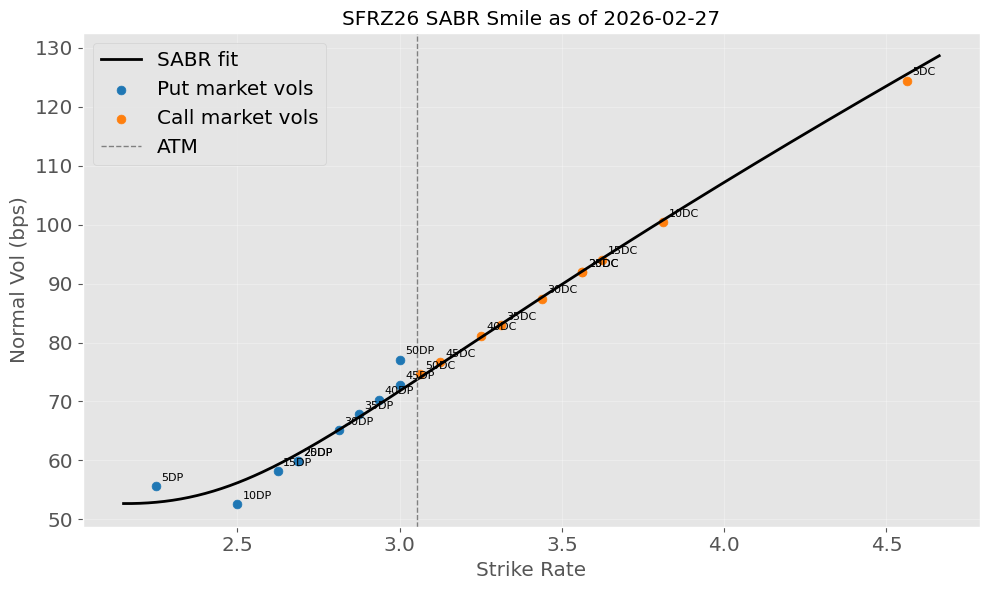

FETCHING EOD DATA FROM BARCHART...: 100%|██████████| 52/52 [00:53<00:00,  1.03s/it]


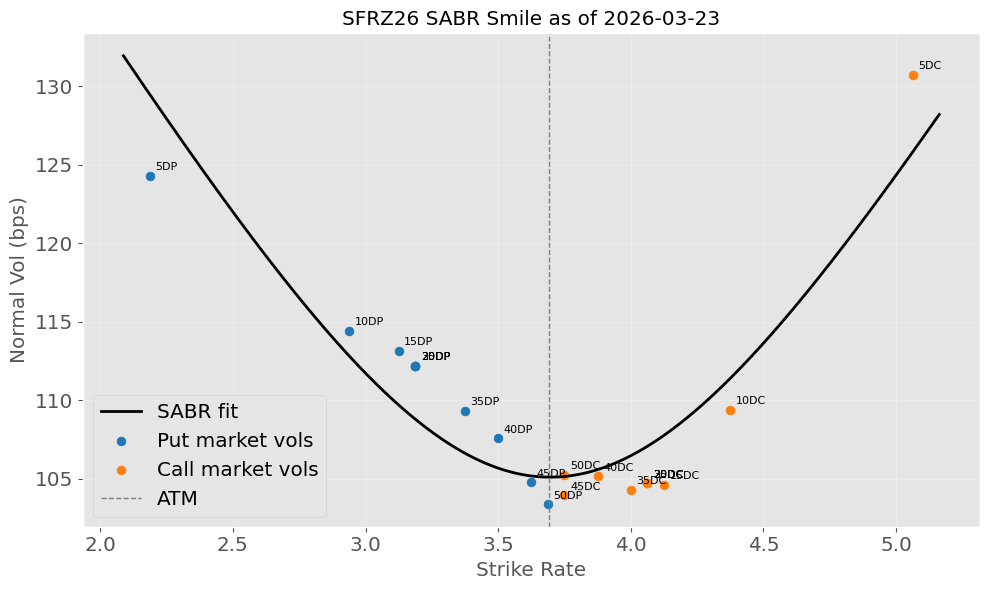

c:\Users\chris\anaconda3\envs\stir\Lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning:

Values in x were outside bounds during a minimize step, clipping to bounds



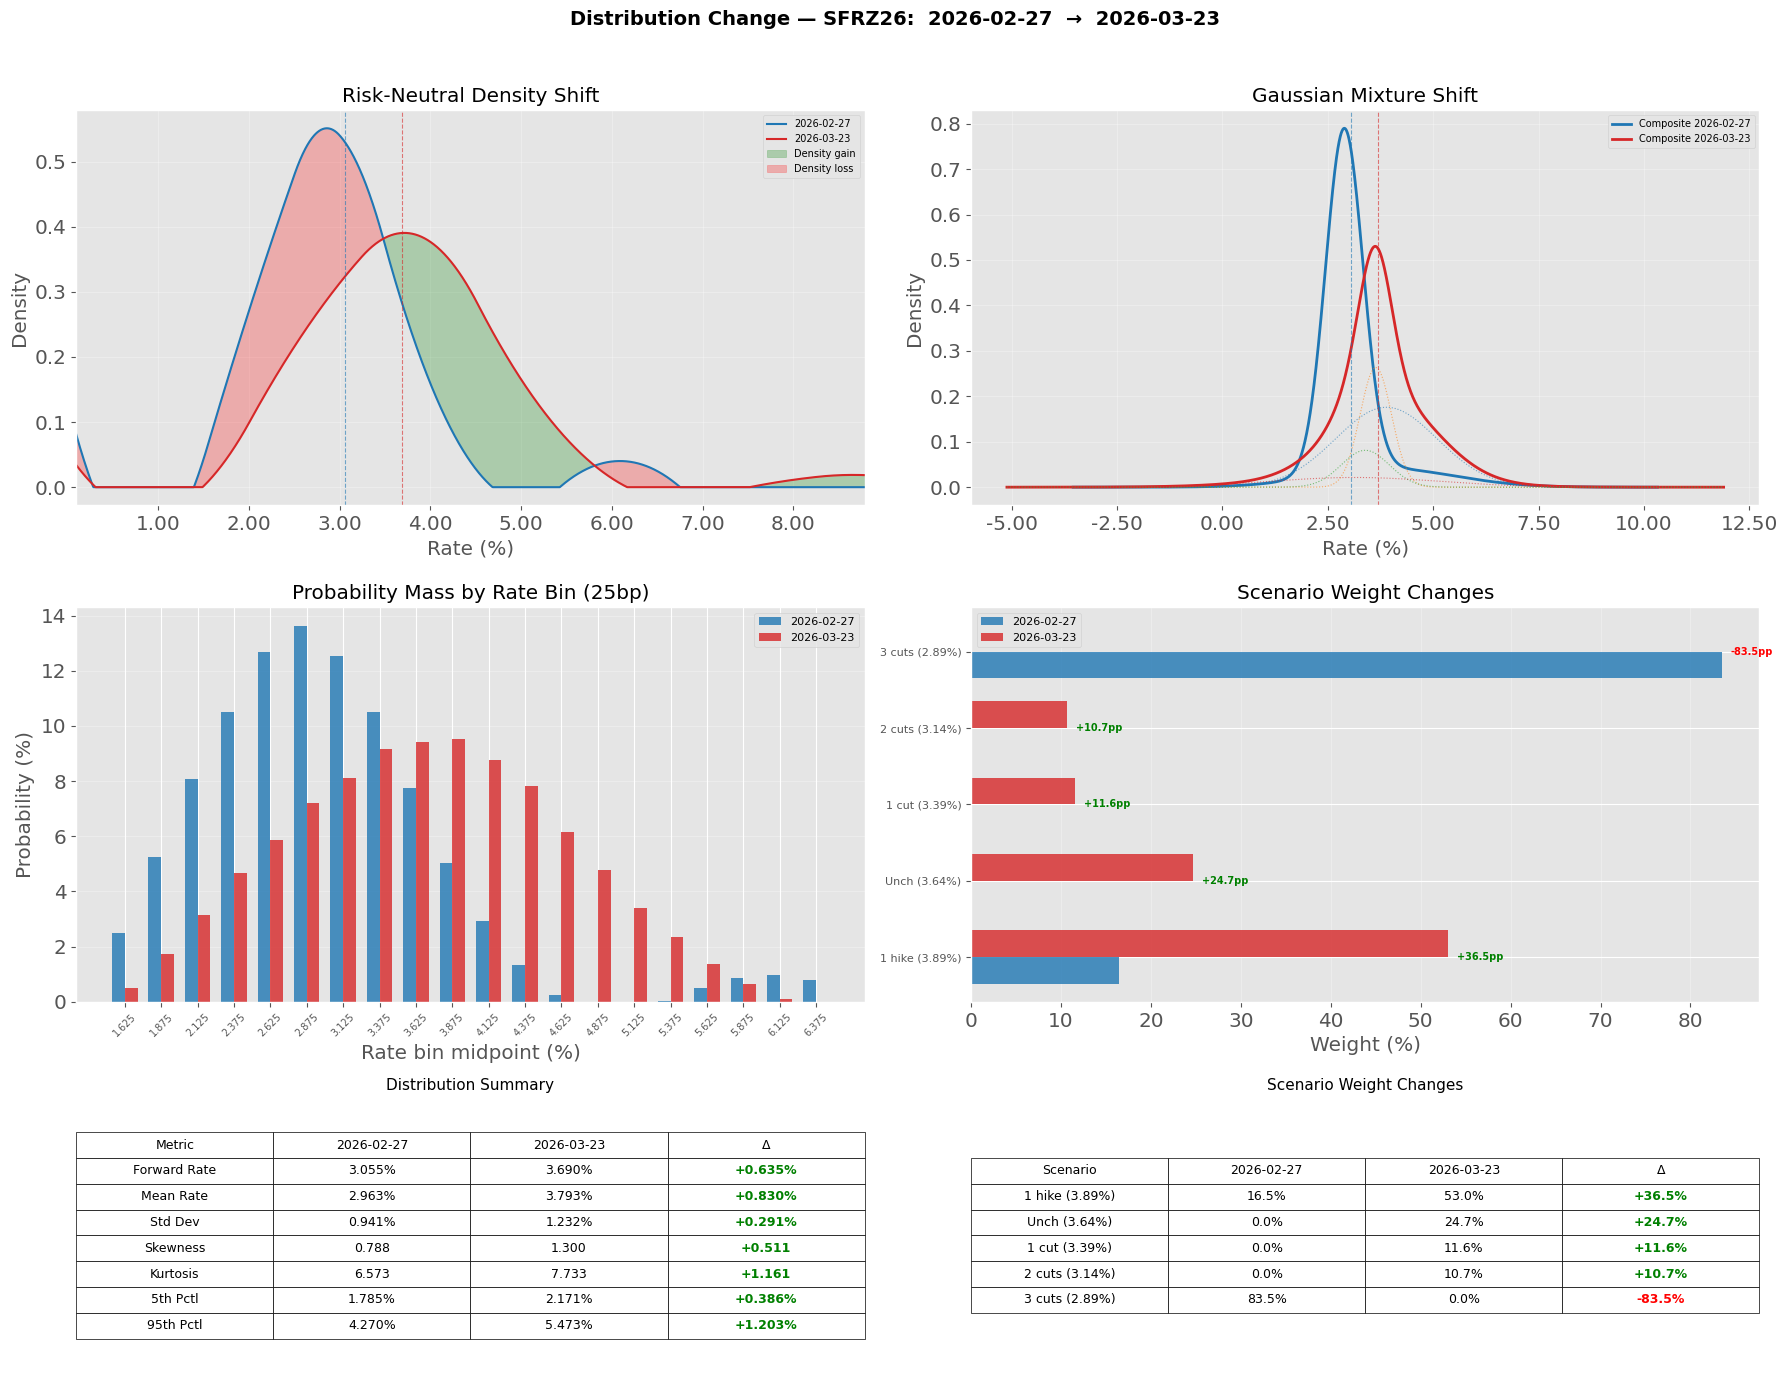

In [7]:
from RVUtils.ImpliedDistribution import (
    SFRImpliedDistribution,
    FedScenarioConfig,
    plot_snapshot_dashboard,
    plot_rnd_comparison,
	plot_distribution_change,
	resolve_strip_symbols,
    plot_strip_distribution_change,
)


config = FedScenarioConfig.default_sofr_scenarios(
    current_rate=3.64, n_cuts_range=[-1, 0, 1, 2, 3]
)
dist = SFRImpliedDistribution(scenario_config=config)

smile1 = stirfo_mdp.fetch_sabr_smile({
    "symbol": "SFRZ26",
    "as_of": datetime.date(2026, 2, 27),
    # "strike_offsets_bps": "listed",
    # "force_refresh": True,
    "show_tqdm": True,
})
plot_sfr_smile(smile1)

smile2 = stirfo_mdp.fetch_sabr_smile({
    "symbol": "SFRZ26",
    "as_of": datetime.date(2026, 3, 23),
    # "as_of": "live", 
    # "strike_offsets_bps": "listed",
    "show_tqdm": True,
})
plot_sfr_smile(smile2)

snap_before, snap_after = dist.compare(smile1, smile2)
fig = plot_distribution_change(snap_before, snap_after)